# Credit Scoring Model
## Exploratory Data Analysis (EDA)

This notebook performs an initial exploratory data analysis for the German Credit dataset. The goal is to understand the structure of the data, inspect data quality, and identify patterns in the target variable before any modeling work begins.

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

np.random.seed(42)

## 2. Load Dataset

In [5]:
from pathlib import Path

data_path = Path('../data/processed/german_credit_processed.csv')
df = pd.read_csv(data_path)

print('Shape of the dataset:')
print(df.shape)
print('\nSample of 5 rows (random):')
display(df.sample(5, random_state=42))
print('\nLast 5 rows:')
display(df.tail())

Shape of the dataset:
(1000, 21)

Sample of 5 rows (random):


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence_years,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
521,A11,18,A32,A43,3190,A61,A73,2,A92,A101,2,A121,24,A143,A152,1,A173,1,A191,A201,bad
737,A11,18,A32,A40,4380,A62,A73,3,A93,A101,4,A123,35,A143,A152,1,A172,2,A192,A201,good
740,A11,24,A31,A40,2325,A62,A74,2,A93,A101,3,A123,32,A141,A152,1,A173,1,A191,A201,good
660,A13,12,A32,A43,1297,A61,A73,3,A94,A101,4,A121,23,A143,A151,1,A173,1,A191,A201,good
411,A14,33,A34,A41,7253,A61,A74,3,A93,A101,2,A123,35,A143,A152,2,A174,1,A192,A201,good



Last 5 rows:


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence_years,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,4,A121,31,A143,A152,1,A172,1,A191,A201,good
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,4,A122,40,A143,A152,1,A174,1,A192,A201,good
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201,good
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,4,A124,23,A143,A153,1,A173,1,A192,A201,bad
999,A12,45,A34,A41,4576,A62,A71,3,A93,A101,4,A123,27,A143,A152,1,A173,1,A191,A201,good


## 3. Dataset Information

In [ ]:
print('Dataset information:')
df.info()
print('\nUnique values per column:')
print(df.nunique())
print('\nDescriptive statistics:')
display(df.describe(include='all').T)
print('\nCategorical column summaries:')
display(df.describe(include='str').T)
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account_status  1000 non-null   str  
 1   duration_months          1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence_years  1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
checking_account_status,1000,4,A14,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_months,1000.00,NaN,NaN,NaN,20.90,12.06,4.00,12.00,18.00,24.00,72.00
credit_history,1000,5,A32,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,A43,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,1000.00,NaN,NaN,NaN,3271.26,2822.74,250.00,1365.50,2319.50,3972.25,18424.00
savings_account,1000,5,A61,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_duration,1000,5,A73,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment_rate,1000.00,NaN,NaN,NaN,2.97,1.12,1.00,2.00,3.00,4.00,4.00
personal_status_sex,1000,4,A93,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_debtors,1000,3,A101,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Categorical column summaries:


C:\Users\Muzammil\AppData\Local\Temp\ipykernel_23344\798463478.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object').T)


,count,unique,top,freq
checking_account_status,1000,4,A14,394
credit_history,1000,5,A32,530
purpose,1000,10,A43,280
savings_account,1000,5,A61,603
employment_duration,1000,5,A73,339
personal_status_sex,1000,4,A93,548
other_debtors,1000,3,A101,907
property,1000,4,A123,332
other_installment_plans,1000,3,A143,814
housing,1000,3,A152,713



Column names:
['checking_account_status', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence_years', 'property', 'age', 'other_installment_plans', 'housing', 'existing_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'credit_risk']

Data types:
checking_account_status      str
duration_months            int64
credit_history               str
purpose                      str
credit_amount              int64
savings_account              str
employment_duration          str
installment_rate           int64
personal_status_sex          str
other_debtors                str
present_residence_years    int64
property                     str
age                        int64
other_installment_plans      str
housing                      str
existing_credits           int64
job                          str
people_liable              int64
telephone

## 4. Missing Values

In [7]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing_values,
    'missing_percentage': missing_percentage
}).sort_values(by='missing_count', ascending=False)

print('Missing values summary:')
display(missing_df[missing_df['missing_count'] > 0])

if missing_df['missing_count'].sum() > 0:
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.xlabel('Columns')
    plt.ylabel('Rows')
    plt.show()
else:
    print('No missing values found in the dataset.')

Missing values summary:


,missing_count,missing_percentage


No missing values found in the dataset.


The missing value analysis highlights whether any columns require special attention during preprocessing. In this notebook, the goal is simply to identify the extent of missingness and note whether it is negligible or significant.

## 5. Duplicate Records

In [8]:
duplicate_count = df.duplicated().sum()
print(f'Duplicate records: {duplicate_count}')

if duplicate_count > 0:
    print('Duplicate rows are present and should be reviewed before modeling.')
else:
    print('No duplicate rows were found in the dataset.')

Duplicate records: 0
No duplicate rows were found in the dataset.


Duplicate records can affect model training and evaluation if they are not handled appropriately. This section confirms whether the dataset contains repeated rows that might introduce bias.

## 6. Target Variable

Target variable counts:
credit_risk
good    700
bad     300
Name: count, dtype: int64

Target variable percentages:
credit_risk
good   70.00
bad    30.00
Name: proportion, dtype: float64


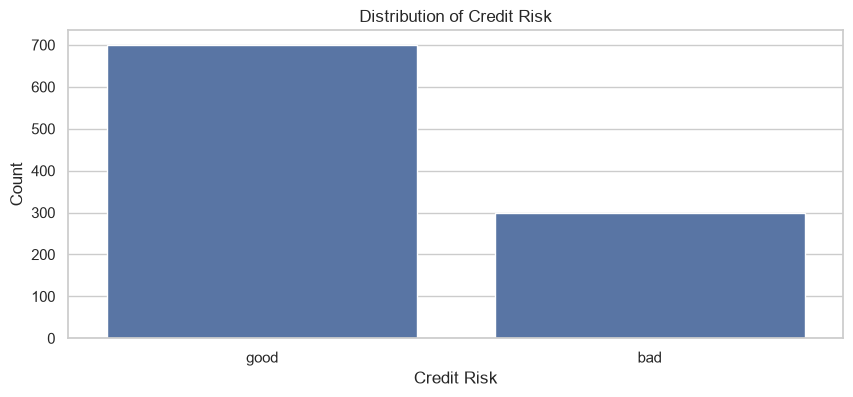

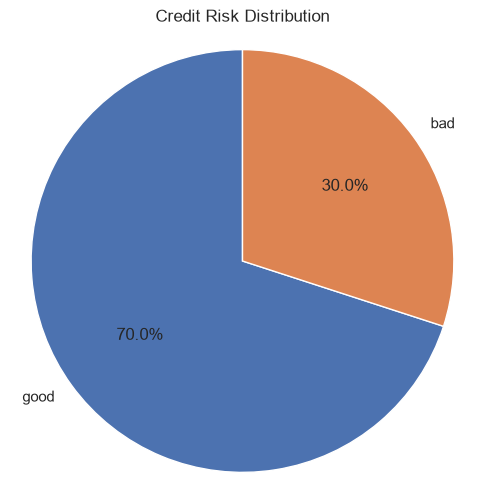

In [9]:
target_counts = df['credit_risk'].value_counts()
target_percentages = df['credit_risk'].value_counts(normalize=True) * 100

print('Target variable counts:')
print(target_counts)
print('\nTarget variable percentages:')
print(target_percentages)

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='credit_risk', order=target_counts.index)
plt.title('Distribution of Credit Risk')
plt.xlabel('Credit Risk')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 6))
plt.pie(target_percentages, labels=target_percentages.index, autopct='%1.1f%%', startangle=90)
plt.title('Credit Risk Distribution')
plt.axis('equal')
plt.show()

The target variable distribution shows whether the dataset is balanced or imbalanced. Class imbalance is important to understand because it can influence evaluation metrics and downstream modeling choices.